In [33]:
import pandas as pd
import numpy as np
from glob import glob
import re
import nltk
import os, re
from pathlib import Path
import re
from pathlib import Path
from nltk.corpus import stopwords
from pathlib import Path

nltk.download('stopwords')
import pandas as pd
import numpy as np
import seaborn as sns
import plotly_express as px
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('tagsets')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package tagsets to
[nltk_data]     /Users/samanthaasefi/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_

True

In [34]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
SENTS = OHCO[:4]
PARAS = OHCO[:3]
CHAPS = OHCO[:2]
BOOKS = OHCO[:1]

bag = CHAPS

In [35]:
data_dir = Path("corpus/f2")

LIB = pd.read_csv(data_dir / "LIB.csv").set_index(['book_id', 'chap_num'])
TOKEN = pd.read_csv(data_dir / "TOKEN.csv").set_index(OHCO)
VOCAB = pd.read_csv(data_dir / "VOCAB.csv").set_index('term_str')

In [36]:
LIB = pd.read_csv(data_dir / "LIB.csv").set_index(BOOKS)

LIB.head()

,chap_num,author,book_title,filepath,source_url,page_title,chapter_title,n_paragraphs_raw
book_id,,,,,,,,
fourier_selections,1,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch01.txt,https://www.marxists.org/reference/archive/fou...,"Charles Fourier, Selections from his Writings",Of the Role of the Passions,41
fourier_selections,2,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch02.txt,https://www.marxists.org/reference/archive/fou...,"Charles Fourier, Selections from his Writings",Of Education,23
fourier_selections,3,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch03.txt,https://www.marxists.org/reference/archive/fou...,Selection from Charles Fourier,“Universal Harmony”,10
fourier_selections,4,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch04.txt,https://www.marxists.org/reference/archive/fou...,Selection from Charles Fourier,“Letter to the High Judge”,43
fourier_selections,5,Charles Fourier,Selections from his Writings,corpus/books/fourier_selections/ch05.txt,https://www.marxists.org/reference/archive/fou...,Selection from Charles Fourier,“Indices and Methods which led to the Discovery”,34


In [37]:
TOKEN = pd.read_csv(data_dir / 'TOKEN.csv').set_index(OHCO)
TOKEN.head()

pos_tuple  \
book_id            chap_num para_num sent_num token_num                            
fourier_selections 1        3        0        2          ('philosophical', 'JJ')   
                                              3                 ('whims', 'NNS')   
                                              4                ('called', 'VBN')   
                                              5                ('duties', 'NNS')   
                                              8               ('relation', 'NN')   

                                                             token_str  pos  \
book_id            chap_num para_num sent_num token_num                       
fourier_selections 1        3        0        2          philosophical   JJ   
                                              3                  whims  NNS   
                                              4                 called  VBN   
                                              5                 duties  NNS   
                                              8               relation   NN   

                                                              term_str  \
book_id            chap_num para_num sent_num token_num                  
fourier_selections 1        3        0        2          philosophical   
                                              3                  whims   
                                              4                 called   
                                              5                 duties   
                                              8               relation   

                                                         is_stop  
book_id            chap_num para_num sent_num token_num           
fourier_selections 1        3        0        2            False  
                                              3            False  
                                              4            False  
                                              5            False  
                                              8            False

In [38]:
VOCAB = pd.read_csv(data_dir / 'VOCAB.csv').set_index('term_str')
VOCAB.head()

,term_id,n,pos_max,num,stop,p_stem
term_str,,,,,,
',0,57,POS,0,0,'
'',1,2,'',0,0,''
'alert,2,1,JJ,0,0,'alert
'area,3,1,POS,0,0,'area
'as,4,1,NN,0,0,'a


# Add Max POS to VOCAB

In [40]:
TOKEN.groupby(['term_str', 'pos']).pos.count()
TOKEN.groupby(['term_str', 'pos']).pos.count().unstack()
TOKEN.groupby(['term_str', 'pos']).pos.count().unstack().idxmax(1)

term_str
'            POS
''            ''
'alert        JJ
'area        POS
'as           NN
            ... 
zealously     RB
zeit         NNP
zeitung      NNP
zone          NN
zones        NNS
Length: 8290, dtype: object

In [41]:
VOCAB['pos_max'] = TOKEN.groupby(['term_str', 'pos']).pos.count().unstack().idxmax(1)
VOCAB.sample(5)

,term_id,n,pos_max,num,stop,p_stem
term_str,,,,,,
louisphilippe,4394,1,NNP,0,0,louisphilipp
coloured,1317,1,VBD,0,0,colour
gained,3202,10,VBN,0,0,gain
'traitor,27,1,NNP,0,0,'traitor
access,84,3,NN,0,0,access


# Compare POS Stats in TOKEN and Vocab

In [42]:
POS = TOKEN.pos.value_counts().to_frame(name='n')
POS.index.name = 'pos_id'

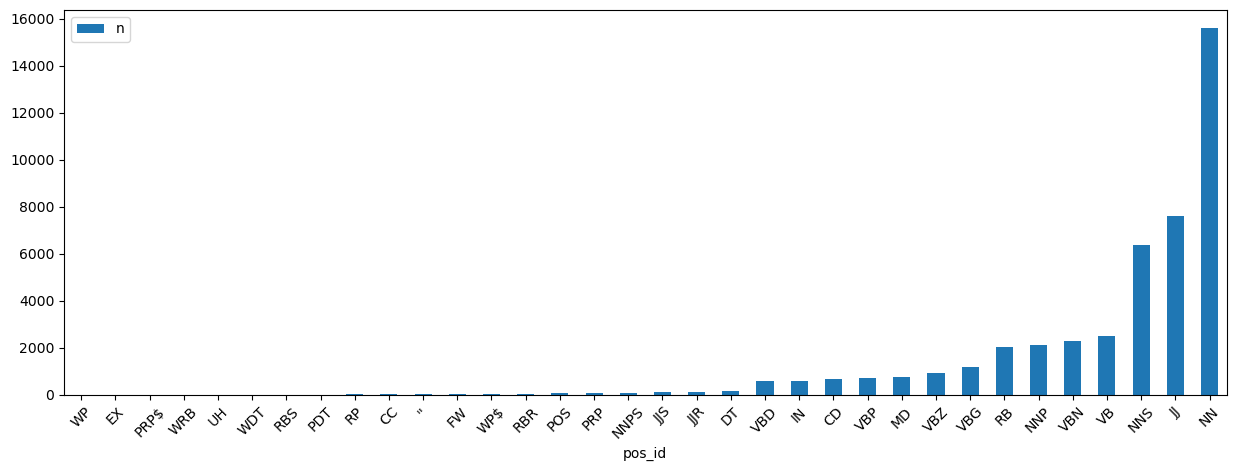

In [43]:
POS.sort_values('n').plot.bar(y='n', figsize=(15,5), rot=45);